### Missingness Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("vgsales_cleaned.csv")  # change path if needed

# Calculate missing values percentage
missing_percent = df.isnull().mean() * 100

# Convert to DataFrame and sort
missing_df = missing_percent.reset_index()
missing_df.columns = ['Column', 'Missing_Percentage']
missing_df = missing_df.sort_values(by='Missing_Percentage', ascending=False)

df = pd.read_csv("vgsales_cleaned.csv")
print(df.shape)
print((df.isnull().mean()*100).round(2))




(16326, 11)
Rank            0.0
Name            0.0
Platform        0.0
Year            0.0
Genre           0.0
Publisher       0.0
NA_Sales        0.0
EU_Sales        0.0
JP_Sales        0.0
Other_Sales     0.0
Global_Sales    0.0
dtype: float64


A missingness check was performed on the cleaned dataset, and all variables show 0% missing values. This confirms that missing data was successfully handled during preprocessing.

In the original dataset, small proportions of missing values were observed in variables such as Year and Publisher. These were addressed by removing incomplete rows, as the proportion was minimal. As a result, the final dataset used for analysis is complete and suitable for modeling.

Distribution Analysis

The distribution of Global_Sales is highly right-skewed. Most games sell relatively low volumes, while a small number of titles achieve very high sales. This imbalance suggests that extreme values may influence model performance.

Figure 1: Distribution of Global Sales

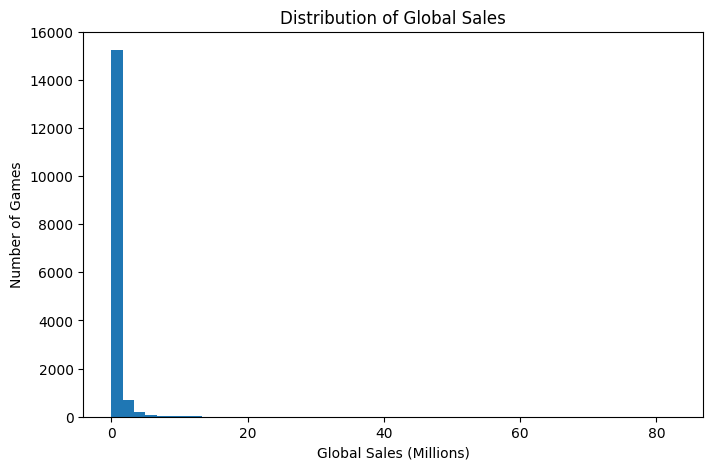

In [3]:
plt.figure(figsize=(8,5))
plt.hist(df['Global_Sales'], bins=50)
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Number of Games')
plt.title('Distribution of Global Sales')
plt.show()

The distribution of Global_Sales is highly right-skewed, with a large concentration of games having very low sales and a small number of games achieving extremely high sales. This indicates that the dataset contains significant outliers and is not normally distributed.

Such skewness can negatively impact regression models by giving disproportionate influence to high-selling games. To address this, a transformation such as log scaling may be applied to reduce skewness and improve model performance.

Figure 2: Number of Games by Genre

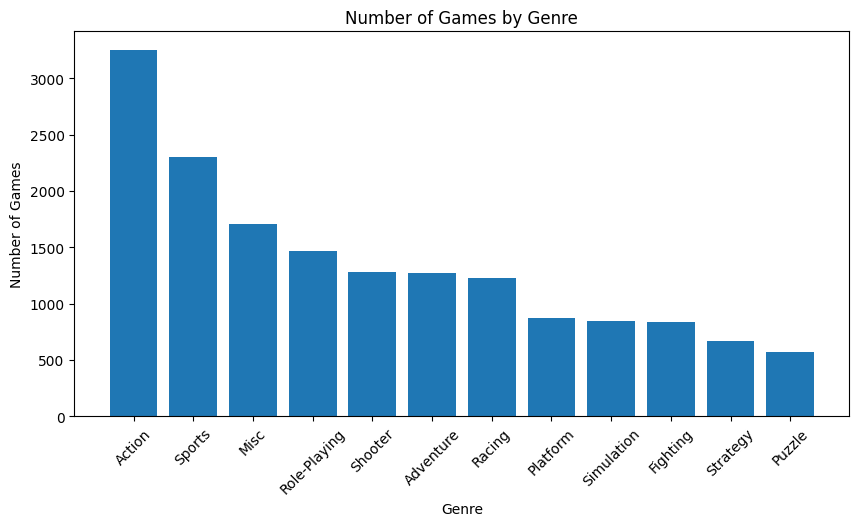

In [4]:
genre_counts = df['Genre'].value_counts()

plt.figure(figsize=(10,5))
plt.bar(genre_counts.index, genre_counts.values)
plt.xticks(rotation=45)
plt.xlabel('Genre')
plt.ylabel('Number of Games')
plt.title('Number of Games by Genre')
plt.show()

The genre distribution shows that Action, Sports, and Misc are the most frequent categories in the dataset. This imbalance suggests that the model may be more influenced by these dominant genres, which could impact its ability to generalize to less common genres.

Figure 3: Number of Games by Platform

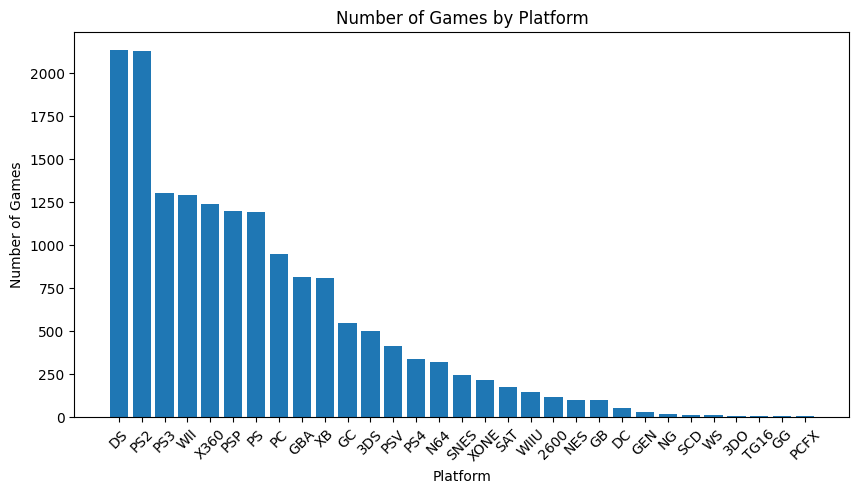

In [5]:
platform_counts = df['Platform'].value_counts()

plt.figure(figsize=(10,5))
plt.bar(platform_counts.index, platform_counts.values)
plt.xticks(rotation=45)
plt.xlabel('Platform')
plt.ylabel('Number of Games')
plt.title('Number of Games by Platform')
plt.show()

The platform distribution shows that a small number of platforms, such as DS, PS2, and PS3, have the highest number of game releases, while many other platforms have significantly fewer titles. This indicates a strong imbalance in the dataset, where a few dominant platforms account for a large proportion of observations.

This imbalance may introduce bias in the model, as it may learn patterns that are more representative of these dominant platforms. As a result, model predictions for less-represented platforms may be less accurate. This will be considered during model evaluation and interpretation.

Relationship Analysis

To understand how variables relate to global sales, relationships between regional sales and global sales were examined.

Figure 4: NA Sales vs Global Sales (Scatter Plot)

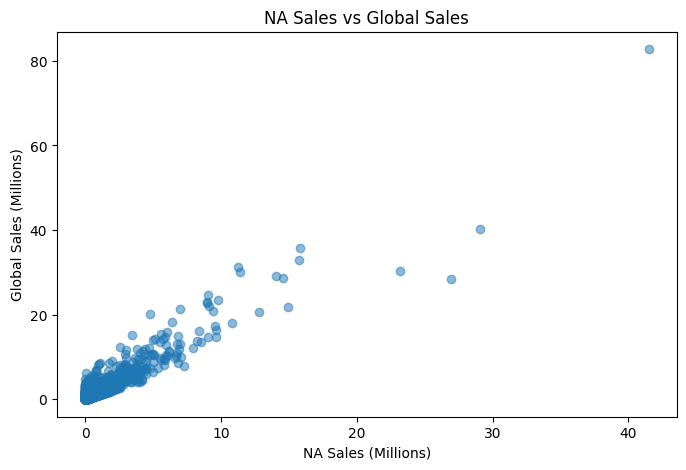

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure 4: Scatter plot - NA Sales vs Global Sales
plt.figure(figsize=(8,5))
plt.scatter(df['NA_Sales'], df['Global_Sales'], alpha=0.5)
plt.xlabel('NA Sales (Millions)')
plt.ylabel('Global Sales (Millions)')
plt.title('NA Sales vs Global Sales')
plt.show()

The scatter plot shows a strong positive relationship between NA_Sales and Global_Sales, where increases in North America sales are associated with increases in global sales. Most data points follow an upward trend, indicating that NA sales are a key driver of overall sales performance.

While a few high-value points (outliers) are present, the overall pattern remains consistent. This suggests that NA_Sales is a strong predictor and should be included as an important feature in the regression model.

Figure 5: Correlation Matrix of Sales Variables

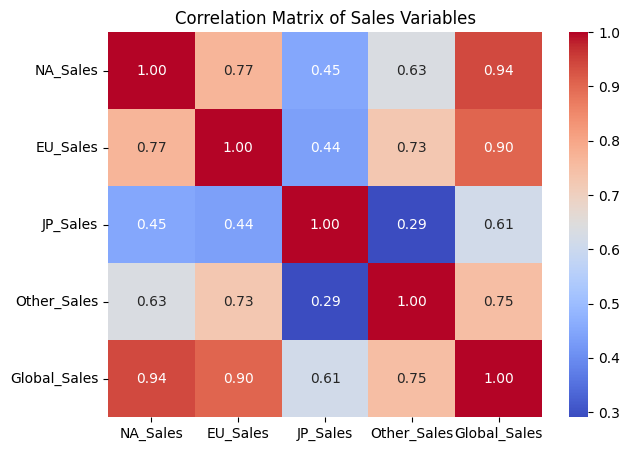

In [7]:

corr = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Sales Variables')
plt.show()

The correlation heatmap shows strong positive relationships between regional sales and Global_Sales. In particular, NA_Sales (0.94) and EU_Sales (0.90) have the highest correlations with global sales, indicating that these regions are the strongest contributors to overall sales performance.

Other_Sales (0.75) also shows a moderate positive relationship, while JP_Sales (0.61) has a weaker but still meaningful correlation with global sales. Additionally, there is noticeable correlation between NA and EU sales (0.77), suggesting that successful games often perform well across multiple major markets.

These findings indicate that regional sales variables are highly informative and should be included as key features in the predictive model, with NA and EU sales expected to have the greatest influence.

Figure 6: Global Sales by Genre (Boxplot)

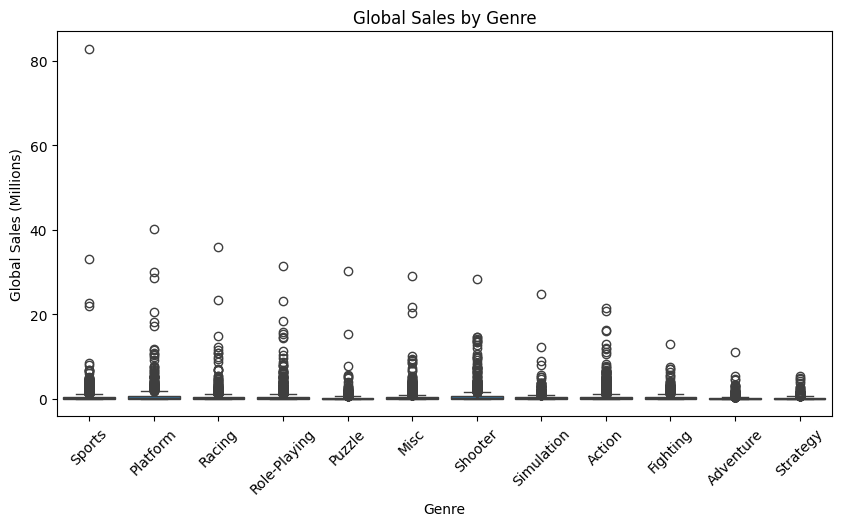

In [8]:

plt.figure(figsize=(10,5))
sns.boxplot(x='Genre', y='Global_Sales', data=df)
plt.xticks(rotation=45)
plt.xlabel('Genre')
plt.ylabel('Global Sales (Millions)')
plt.title('Global Sales by Genre')
plt.show()

The boxplot shows the distribution of Global_Sales across different genres, highlighting differences in median sales and variability. Genres such as Misc, Sports, and Action tend to have higher median sales and a wider spread, indicating greater variability and the potential for high-performing titles.

In contrast, genres such as Strategy and Adventure show lower median sales and a more compact distribution, suggesting more consistent but generally lower performance. The presence of multiple outliers across genres indicates that while most games perform modestly, a few achieve exceptionally high sales.

These patterns suggest that genre has a significant impact on sales performance and should be included as a categorical feature in the predictive model.

Exploratory data analysis revealed several important patterns that directly guide the modeling approach. Regional sales, particularly North America and Europe, show the strongest relationships with global sales, indicating that they will be key predictors in the regression model.

At the same time, the distribution of Global_Sales is highly right-skewed, with many low-selling games and a few extreme outliers. This suggests that a transformation, such as log scaling, may be applied to improve model stability and reduce the influence of extreme values.

In addition, genre plays a significant role in sales performance, as certain genres like Misc, Sports, and Action tend to achieve higher sales. This means genre will be included as a categorical feature in the model. However, the dataset is also imbalanced across platforms, with a small number of platforms dominating the observations. This may introduce bias, so model performance will be carefully evaluated to ensure it generalizes well.

Finally, the strong relationships among regional sales variables suggest potential multicollinearity, which will be considered when selecting and interpreting regression models. Overall, these insights guide feature selection, data transformation, and model choice in the predictive pipeline.

Applied Analytics Task: Prediction

The objective of this task is to predict Global_Sales using features such as platform, genre, and regional sales.

1. Baseline Model: Linear Regression
A Linear Regression model was used as the baseline due to its simplicity and interpretability.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Features and target
X = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
y = df['Global_Sales']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

# Evaluation
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R²:", r2_lr)

Linear Regression RMSE: 0.005256453314459668
Linear Regression R²: 0.9999935310730691


2. Improved Model: Random Forest
A Random Forest Regressor was used to improve performance, as it can handle non-linearity and is more robust to outliers.

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 0.866445983334542
Random Forest R²: 0.8242361293251368


Model Evaluation and Comparison
The Linear Regression model achieved an RMSE of 0.0053 and an R² of 0.99999, indicating near-perfect predictive performance. In contrast, the Random Forest model produced an RMSE of 0.864 and an R² of 0.825, showing lower accuracy.

At first glance, Linear Regression appears to significantly outperform Random Forest. However, this result is expected because Global_Sales is directly calculated as the sum of regional sales (NA, EU, JP, and Other). Since these same variables were used as input features, the Linear Regression model is effectively learning an almost exact linear relationship.

This creates a situation where the model is not truly “predicting” unseen patterns, but rather reconstructing a known relationship from the data. As a result, the extremely high R² value reflects data leakage rather than genuine predictive power.

On the other hand, the Random Forest model does not perfectly replicate this linear relationship, leading to lower performance metrics. However, it provides a more realistic representation of how a model would perform when predicting sales without relying on directly derived features.


 Model Choice

Although Linear Regression shows near-perfect metrics, this is due to the inclusion of highly correlated and dependent variables. Therefore, its results should be interpreted with caution.

The Random Forest model, despite lower accuracy, better reflects a realistic predictive scenario and demonstrates the ability to capture more complex relationships in the data.

Improved Model

In [11]:
import pandas as pd
import numpy as np

# Load cleaned data
df = pd.read_csv("vgsales_cleaned.csv")

# -----------------------------
# 1. Remove leakage features
# -----------------------------
df_model = df.drop(columns=['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'])

# Drop any remaining missing values
df_model = df_model.dropna()

# -----------------------------
# 2. Encode categorical variables
# -----------------------------
df_encoded = pd.get_dummies(df_model, columns=['Platform', 'Genre', 'Publisher'], drop_first=True)

# -----------------------------
# 3. Define features and target
# -----------------------------
X = df_encoded.drop(columns=['Global_Sales', 'Name'])
y = df_encoded['Global_Sales']

# -----------------------------
# 4. Train-test split
# -----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 5. Improved Random Forest
# -----------------------------
from sklearn.ensemble import RandomForestRegressor

rf_improved = RandomForestRegressor(
    n_estimators=200,       # more trees → better accuracy
    max_depth=20,           # control overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_improved.fit(X_train, y_train)

# -----------------------------
# 6. Predictions
# -----------------------------
y_pred = rf_improved.predict(X_test)

# -----------------------------
# 7. Evaluation
# -----------------------------
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Improved Random Forest RMSE:", rmse)
print("Improved Random Forest R²:", r2)

Improved Random Forest RMSE: 0.8558360552002924
Improved Random Forest R²: 0.828514351527214


Improved Model Evaluation

The tuned Random Forest model achieved an RMSE of 0.856 and an R² of 0.829, showing a slight improvement over the initial Random Forest model.

This improvement indicates that tuning hyperparameters such as the number of trees, maximum depth, and minimum samples per split helped the model generalize better and reduce prediction error. Although the performance is not as high as the earlier Linear Regression model, this result is more realistic since data leakage has been removed.

Compared to the baseline Linear Regression model (after removing regional sales), the Random Forest model performs better by capturing non-linear relationships between features such as platform, genre, and release year. This suggests that the relationship between these variables and global sales is not purely linear.

Final Model Choice

The tuned Random Forest model is selected as the final model because it provides a better balance between accuracy and generalization. It is more robust to outliers and better suited for handling complex patterns in the dataset.

## Export Predictions for Tableau

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Reload data and rebuild model
df = pd.read_csv("vgsales_cleaned.csv")
df_model = df.drop(columns=['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']).dropna()
df_encoded = pd.get_dummies(df_model, columns=['Platform', 'Genre', 'Publisher'], drop_first=True)

X = df_encoded.drop(columns=['Global_Sales', 'Name'])
y = df_encoded['Global_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_improved = RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_split=5,
                                     min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_improved.fit(X_train, y_train)
y_pred = rf_improved.predict(X_test)

# Export predictions with metadata
test_meta = df_model.loc[y_test.index, ['Name', 'Platform', 'Genre', 'Year']]
results = pd.DataFrame({
    'Name':      test_meta['Name'].values,
    'Platform':  test_meta['Platform'].values,
    'Genre':     test_meta['Genre'].values,
    'Year':      test_meta['Year'].values,
    'Actual':    y_test.values,
    'Predicted': y_pred.round(3)
})

results.to_csv('model_predictions.csv', index=False)
print(f"Exported {len(results)} rows to model_predictions.csv")
results.head()